In [44]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Add two child directories
child_dir_1 = os.path.join(current_dir, "dynamic_trend_model")
child_dir_2 = os.path.join(current_dir, "gru_predictor")

for child_dir in [child_dir_1, child_dir_2]:
    if child_dir not in sys.path:
        sys.path.insert(0, child_dir)

print(f"Added to path: {current_dir}")
print(f"Added to path: {child_dir_1}")
print(f"Added to path: {child_dir_2}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka
Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\dynamic_trend_model
Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\gru_predictor


In [55]:
import pandas as pd
import numpy as np
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

def pick_random_file(df_seasonal, df_local, params=None, seed=42):
    """
    params: list of dicts, e.g.
        [
            {"name": "window_size", "value": 12, "comparator": ">="},
            {"name": "status", "value": "success", "comparator": "=="},
        ]
    seed: integer or None, forwarded to pandas.sample(random_state=seed)
    """
    if params is None or len(params) == 0:
        candidates = df_seasonal.copy()
    else:
        candidates =get_candidates(df_seasonal, params=params)

    if candidates.empty:
        raise ValueError("No rows match the given condition(s).")

    row = candidates.sample(1, random_state=seed).iloc[0]
    #print(row)
    
    filename = row["filename"]
    
    row_local = df_local[df_local['filename'] == filename].squeeze()
    #print(row_local)
    
    # union of all columns
    all_cols = row.index.union(row_local.index)
    
    cmp = pd.DataFrame(
        [
            row.reindex(all_cols),
            row_local.reindex(all_cols),
        ],
        index=["seasonal", "local_linear"],
    )

    display(cmp.T)
        
    return filename



In [57]:
def _prepare_time_filtered_df(df, start_date=None, end_date=None):
    """Helper: ensure datetime and filter by dates."""
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df["timestamp_utc"]):
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)

        if start_date is not None:
            df = df[df["timestamp_utc"] >= start_date]
        if end_date is not None:
            df = df[df["timestamp_utc"] <= end_date]

    return df


def plot_water_meter_anomalies(
    df_actuals,
    df_predicted,
    ref_mean,
    ref_std,
    df_predicted_2=None,
    ref_mean_2=None,
    ref_std_2=None,
    model_1_label="Model 1",
    model_2_label="Model 2",
    figsize=(14, 8),
    title="Example of Daily + Weekly Fourier and GRU Predictions with 3σ Bands",
    start_date=None,
    end_date=None,
    save_path=None,
):
    """
    df_actuals:    columns timestamp_utc, Diff
    df_predicted:  columns timestamp_utc, predicted, residual, is_anomaly_predicted, is_anomaly_actual
    df_predicted_2 (optional): same structure as df_predicted, for a second model
    ref_mean_2, ref_std_2 (optional): reference statistics for the second model's 3-sigma band
    model_1_label: legend label for the first model
    model_2_label: legend label for the second model
    """

    # --- Colour palette ---
    COLOR_ACTUAL   = "#2E86AB"
    COLOR_MODEL_1  = "#A23B72"
    COLOR_BAND_1   = "#A23B72"
    COLOR_MODEL_2  = "#F18F01"
    COLOR_BAND_2   = "#E65C00"
    COLOR_ANOM_PRED = "#F18F01"
    COLOR_ANOM_ACT  = "#FF03CD"

    def _add_sigma_band(df_p, ref_mean, ref_std):
        """Attach upper/lower band columns to a predictions dataframe."""
        if df_p is None or df_p.empty or ref_mean is None or ref_std is None:
            return df_p
        band = ref_mean + 3 * ref_std
        df_p = df_p.copy()
        df_p["upper_band"] = df_p["predicted"] + band
        df_p["lower_band"] = df_p["predicted"] - band
        return df_p

    df_p1 = _add_sigma_band(df_predicted, ref_mean, ref_std)
    df_p2 = _add_sigma_band(df_predicted_2, ref_mean_2, ref_std_2)

    # --- Filter by date ---
    df_a  = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p1 = _prepare_time_filtered_df(df_p1, start_date, end_date)
    if df_p2 is not None:
        df_p2 = _prepare_time_filtered_df(df_p2, start_date, end_date)

    # --- Update title if zoomed ---
    #if start_date is not None and end_date is not None:
    #    if isinstance(start_date, str):
    #        start_date = pd.to_datetime(start_date)
    #    if isinstance(end_date, str):
    #        end_date = pd.to_datetime(end_date)
    #    date_range = (
    #        f" ({start_date.strftime('%Y-%m-%d %H:%M')} "
    #        f"to {end_date.strftime('%Y-%m-%d %H:%M')})"
    #    )
    #    title = title + date_range

    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    # --- Actuals ---
    ax.plot(
        df_a["timestamp_utc"],
        df_a["Diff"],
        color=COLOR_ACTUAL,
        linewidth=2.5,
        marker="o",
        markersize=5,
        label="Actual (Diff)",
        zorder=3,
        alpha=0.9,
    )

    # --- Helper: plot one model's prediction + band + anomalies ---
    def _plot_model(df_p, color_line, color_band, pred_label, band_label, anom_zorder, pred_anom_marker="X"):
        if df_p is None or df_p.empty:
            return

        ax.plot(
            df_p["timestamp_utc"],
            df_p["predicted"],
            color=color_line,
            linewidth=2,
            marker="s",
            markersize=4,
            label=pred_label,
            zorder=2,
            alpha=0.8,
            linestyle="--",
        )

        if "upper_band" in df_p.columns and "lower_band" in df_p.columns:
            ax.plot(
                df_p["timestamp_utc"],
                df_p["upper_band"],
                color=color_band,
                linestyle=":",
                linewidth=1.5,
                label=f"3σ band ({band_label})",
                zorder=1,
                alpha=0.6,
            )
            ax.plot(
                df_p["timestamp_utc"],
                df_p["lower_band"],
                color=color_band,
                linestyle=":",
                linewidth=1.5,
                zorder=1,
                alpha=0.6,
            )

        if "is_anomaly_predicted" in df_p.columns:
            anomalies = df_p[df_p["is_anomaly_predicted"] == 1]
            if len(anomalies) > 0:
                ax.scatter(
                    anomalies["timestamp_utc"],
                    anomalies["actual"],
                    color=COLOR_ANOM_PRED,
                    s=150,
                    marker=pred_anom_marker,  # <-- uses the passed marker
                    label=f"Anomaly Predicted ({band_label})",
                    zorder=anom_zorder,
                    edgecolors="#C41E3A",
                    linewidth=2,
                )

        if "is_anomaly_actual" in df_p.columns:
            anomalies = df_p[df_p["is_anomaly_actual"] != 0]
            if len(anomalies) > 0:
                ax.scatter(
                    anomalies["timestamp_utc"],
                    anomalies["actual"],
                    color=COLOR_ANOM_ACT,
                    s=150,
                    marker="P",
                    label=f"Anomaly Actual ({band_label})",
                    zorder=anom_zorder + 1,
                    edgecolors="#C41E3A",
                    linewidth=2,
                )

    _plot_model(df_p1, COLOR_MODEL_1, COLOR_BAND_1, f"Predicted ({model_1_label})", model_1_label, anom_zorder=4, pred_anom_marker="X")
    _plot_model(df_p2, COLOR_MODEL_2, COLOR_BAND_2, f"Predicted ({model_2_label})", model_2_label, anom_zorder=5, pred_anom_marker="*")

    # --- Axis formatting ---
    ax.set_xlabel("Timestamp (UTC)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Water Consumption (Diff)", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)

    timestamps = []
    for d in filter(lambda x: x is not None and not x.empty, [df_a, df_p1, df_p2]):
        timestamps.append(d["timestamp_utc"].min())
        timestamps.append(d["timestamp_utc"].max())

    if timestamps:
        t_min, t_max = min(timestamps), max(timestamps)
        time_range = (t_max - t_min).total_seconds()
    else:
        time_range = 0

    if time_range < 3600:
        date_format, date_locator = "%H:%M:%S", mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format, date_locator = "%H:%M", mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format, date_locator = "%Y-%m-%d %H:%M", mdates.AutoDateLocator()
    else:
        date_format, date_locator = "%Y-%m-%d", mdates.AutoDateLocator()

    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=12, framealpha=0.95)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("white")
    fig.tight_layout()
    
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())

    return fig, ax

    return fig, ax

In [48]:
df_metrics_seasonal = pd.read_csv('dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_test.csv')
df_metrics_weekly = pd.read_csv('gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_anomalies_test.csv')

filename = pick_random_file(
    df_metrics_seasonal,
    df_metrics_weekly,
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        {"name": "metric_mape", "value": 1, "comparator": "<"},
    ],
    seed=87,
)
meter_id = 147336
#147336

,seasonal,local_linear
anomaly_indices,"[31, 47, 66, 82, 93, 95, 103, 115, 117, 126, 1...","[31, 44, 46, 54, 63, 73, 79, 88, 91, 94, 101, ..."
anomaly_indices_robust,"[31, 47, 54, 66, 82, 93, 95, 103, 115, 117, 12...","[31, 44, 46, 53, 54, 63, 73, 79, 88, 91, 94, 1..."
converged_second,True,True
converged_train,True,True
df_samples,NaN,981.0
...,...,...
train_train_time_seconds,0.518554,10.422595
warmstart_final_loss,NaN,0.115998
warnflag_second,NaN,NaN
warnflag_train,NaN,NaN


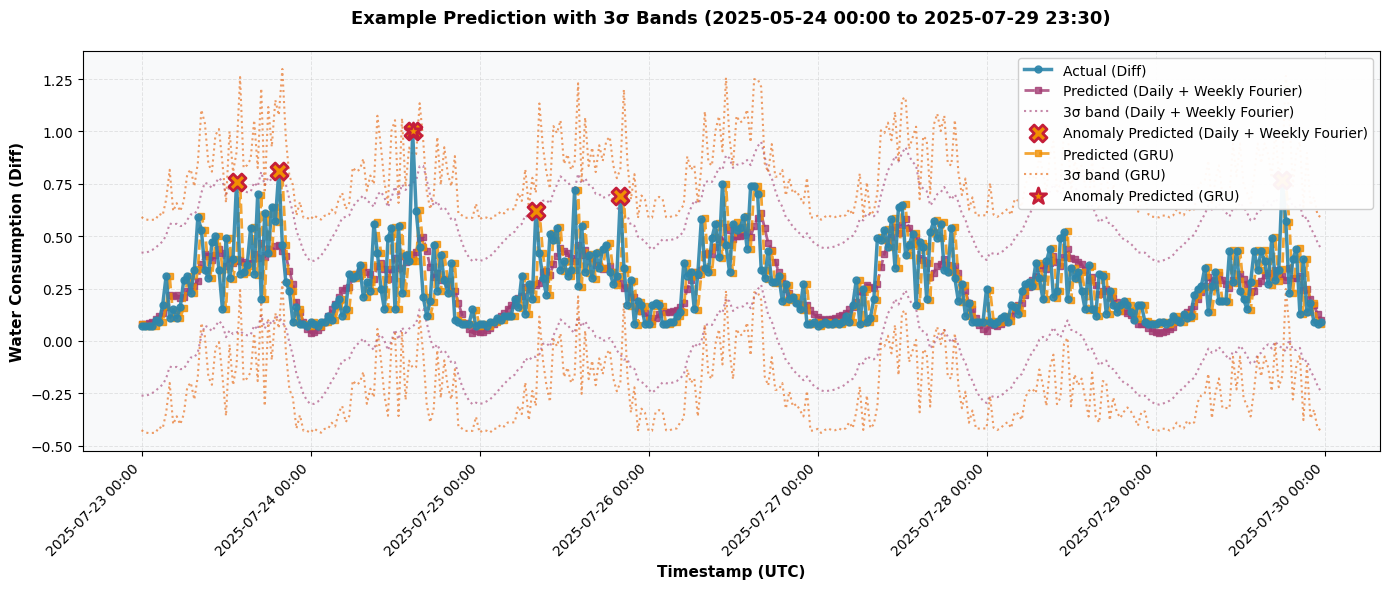

In [49]:
from local_level_unobserved_components_next_one_step_pred import process_single_meter
result = process_single_meter(f'./data_w_diff_001/{meter_id}.csv', predictions_output_csv='./test_pred_uc.csv', weekly_seasonality=True, daily_steps=False)
ref_mean = result['ref_mean']
ref_std = result['ref_std']

df_predicted = pd.read_csv('./test_pred_uc.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

from run_gru_one_step_predict import process_single_meter
result2 = process_single_meter(f'./data_w_diff_001/{meter_id}.csv', predictions_output_csv='./test_pred_gru.csv')
ref_mean2 = result2['ref_mean']
ref_std2 = result2['ref_std']

df_predicted2 = pd.read_csv('./test_pred_gru.csv')
df_predicted2['timestamp_utc'] = pd.to_datetime(df_predicted2['timestamp_utc'])

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, ref_mean=ref_mean, ref_std=ref_std, model_1_label="Daily + Weekly Fourier",
                                        df_predicted_2=df_predicted2, ref_mean_2=ref_mean2, ref_std_2=ref_std2, model_2_label="GRU",
                                        start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] - pd.Timedelta(days=60),
                                        end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1])

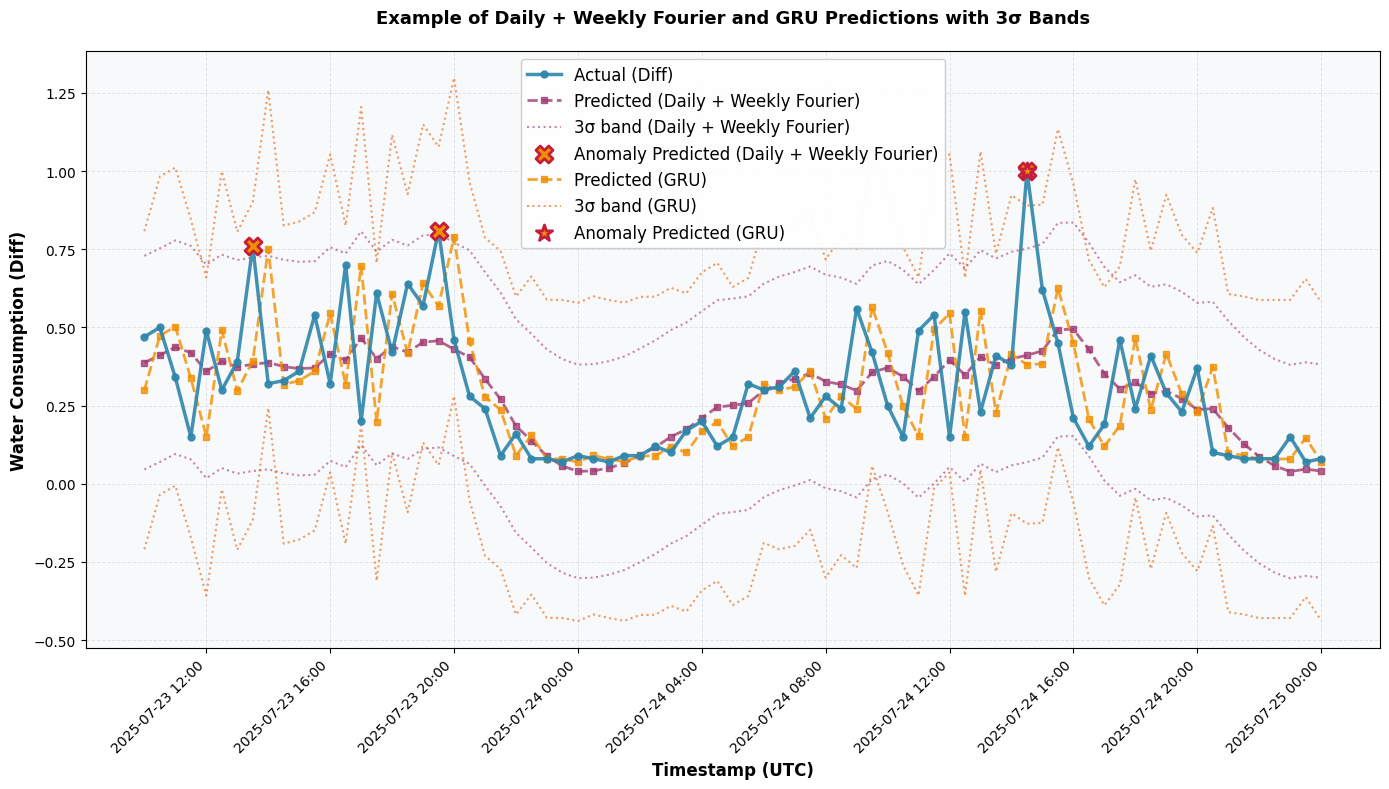

In [58]:
fig2, ax2 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, ref_mean=ref_mean, ref_std=ref_std, model_1_label="Daily + Weekly Fourier",
                                        df_predicted_2=df_predicted2, ref_mean_2=ref_mean2, ref_std_2=ref_std2, model_2_label="GRU",
                                        start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] + pd.Timedelta(hours=10),
                                        end_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] + pd.Timedelta(days=2),
                                        save_path="template/images/example_prediction.png")